In [1]:
import kagglehub
path = kagglehub.dataset_download("mohammedalrajeh/quran-recitations-for-audio-classification")

In [ ]:
import random
import torch
from torch import nn
from torch.optim import Adam
import librosa
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage.transform import resize
import time
import os

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
if device == 'cpu':
    torch.set_num_threads(max(1, os.cpu_count() // 2))
    print('Using CPU with', torch.get_num_threads(), 'threads')
else:
    print('Using GPU')
print(device)


cuda


In [3]:
print(os.listdir(path))

['Dataset', 'files_paths.csv']


In [4]:
df = pd.read_csv(os.path.join(path, 'files_paths.csv'))
df.head()

,FilePath,Class
0,./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav,Mohammed_Aluhaidan
1,./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav,Mohammed_Aluhaidan
2,./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav,Mohammed_Aluhaidan
3,./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav,Mohammed_Aluhaidan
4,./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav,Mohammed_Aluhaidan


In [5]:
df['FilePath'] = df['FilePath'].apply(lambda x: os.path.join(path,'Dataset', x.replace('./', '')))
label_encoder = LabelEncoder()
df['Class_encoded'] = label_encoder.fit_transform(df['Class'])
df.head()

,FilePath,Class,Class_encoded
0,/kaggle/input/datasets/mohammedalrajeh/quran-r...,Mohammed_Aluhaidan,6
1,/kaggle/input/datasets/mohammedalrajeh/quran-r...,Mohammed_Aluhaidan,6
2,/kaggle/input/datasets/mohammedalrajeh/quran-r...,Mohammed_Aluhaidan,6
3,/kaggle/input/datasets/mohammedalrajeh/quran-r...,Mohammed_Aluhaidan,6
4,/kaggle/input/datasets/mohammedalrajeh/quran-r...,Mohammed_Aluhaidan,6


In [6]:
print(df['Class'].unique())
print(df['Class'].value_counts())

['Mohammed_Aluhaidan' 'Yasser_Aldossary' 'Maher_Almuaiqly'
 'Nasser_Alqutami' 'AbdulBari_Althubaity' 'Bander_Balilah'
 'Ali_Alhothaify' 'Saud_Alshuraim' 'Mohammed_Ayoub' 'AbdulRahman_Alsudais'
 'Saad_Alghamdi' 'Abdullah_Albuaijan']
Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Ali_Alhothaify          576
Bander_Balilah          576
Maher_Almuaiqly         576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64


In [7]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6687 entries, 0 to 6686
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   FilePath       6687 non-null   object
 1   Class          6687 non-null   object
 2   Class_encoded  6687 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 156.9+ KB


None

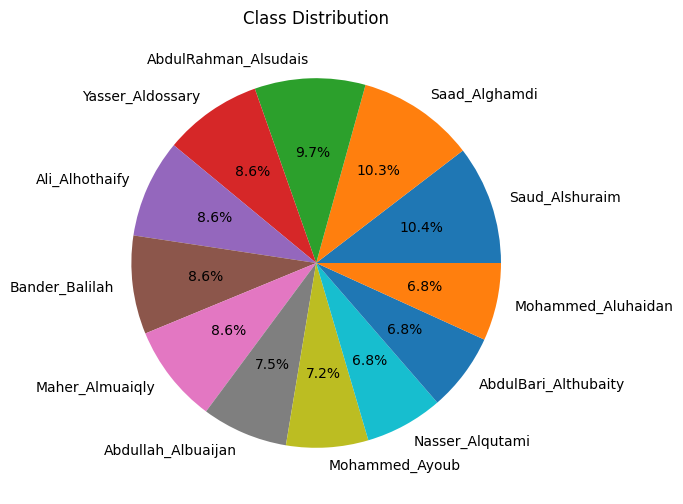

In [8]:
plt.figure(figsize=(10,6))
plt.pie(df['Class'].value_counts(),labels=df['Class'].value_counts().index,autopct="%1.1f%%")
plt.title("Class Distribution")
plt.show()

In [9]:
train=df.sample(frac=0.7,random_state=7)
test=df.drop(train.index)
val=test.sample(frac=0.5,random_state=7)
test=test.drop(val.index)

print(f'Train shape {train.shape}\nTest Shape {test.shape}\nValidation Shape {val.shape}')

Train shape (4681, 3)
Test Shape (1003, 3)
Validation Shape (1003, 3)


In [ ]:
class CustomAudioDataset(Dataset):
    def __init__(self, dataframe, device):
        self.dataframe = dataframe.reset_index(drop=True)
        self.device = device
        self.labels = torch.tensor(list(dataframe['Class_encoded']), dtype=torch.long)
        self.audios = [self.get_spectogram(path) for path in dataframe['FilePath']]

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        audio = torch.tensor(self.audios[idx], dtype=torch.float32).unsqueeze(0)
        label = self.labels[idx]
        return audio, label

    def get_spectogram(self, file_path):
        sr = 22050
        duration = 5

        img_height = 128
        img_width = 256

        signal, sr = librosa.load(file_path, sr=sr, duration=duration)
        spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)

        spec_resized = librosa.util.fix_length(spec_db, size=(duration * sr) // 512 + 1)
        spec_resized = resize(spec_resized, (img_height, img_width), anti_aliasing=True)

        return spec_resized


In [ ]:
train_dataset = CustomAudioDataset(dataframe=train, device=device)
test_dataset = CustomAudioDataset(dataframe=test, device=device)
val_dataset = CustomAudioDataset(dataframe=val, device=device)


In [ ]:
LR = 1e-4
BATCH_SIZE = 8
epochs = 10
checkpoint_path = 'model_checkpoint.pt'


In [13]:
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=True)

In [ ]:
class Net(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(64 * 16 * 32, 1024)
    self.linear2 = nn.Linear(1024, 256)
    self.output = nn.Linear(256, num_classes)

    self.dropout = nn.Dropout(0.3)

  def forward(self, x):
    x = self.relu(self.conv1(x))
    x = self.pooling(x)

    x = self.relu(self.conv2(x))
    x = self.pooling(x)

    x = self.relu(self.conv3(x))
    x = self.pooling(x)

    x = self.flatten(x)
    x = self.dropout(self.relu(self.linear1(x)))
    x = self.dropout(self.relu(self.linear2(x)))
    x = self.output(x)

    return x


In [ ]:
num_classes = len(df['Class_encoded'].unique())
model = Net(num_classes).to(device)
print(model)


Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [16]:
from torchsummary import summary
summary(model,(1,128,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
            Conv2d-3          [-1, 32, 64, 128]           4,640
         MaxPool2d-4           [-1, 32, 32, 64]               0
            Conv2d-5           [-1, 64, 32, 64]          18,496
         MaxPool2d-6           [-1, 64, 16, 32]               0
           Flatten-7                [-1, 32768]               0
            Linear-8                 [-1, 4096]     134,221,824
           Dropout-9                 [-1, 4096]               0
           Linear-10                 [-1, 1024]       4,195,328
          Dropout-11                 [-1, 1024]               0
           Linear-12                  [-1, 512]         524,800
          Dropout-13                  [-1, 512]               0
           Linear-14                   

In [17]:
criterion=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(),lr=LR)

In [ ]:
total_loss_train_plot=[]
total_loss_val_plot=[]
total_acc_train_plot=[]
total_acc_val_plot=[]

start_time=time.time()

for epoch in range(epochs):
  model.train()
  total_acc_train=0
  total_acc_val=0
  total_loss_train=0
  total_loss_val=0

  for inputs,labels in train_loader:
    optimizer.zero_grad()
    inputs=inputs.to(device)
    labels=labels.to(device)

    outputs=model(inputs)
    train_loss=criterion(outputs,labels)
    total_loss_train+=train_loss.item()

    train_loss.backward()

    train_acc=(torch.argmax(outputs,axis=1)==labels).sum().item()
    total_acc_train+=train_acc
    optimizer.step()

  model.eval()
  with torch.no_grad():
    for inputs,labels in val_loader:
      inputs=inputs.to(device)
      labels=labels.to(device)

      outputs=model(inputs)
      val_loss=criterion(outputs,labels)
      total_loss_val+=val_loss.item()

      val_acc=(torch.argmax(outputs,axis=1)==labels).sum().item()
      total_acc_val+=val_acc

  avg_train_loss = total_loss_train / len(train_loader)
  avg_val_loss = total_loss_val / len(val_loader)
  train_accuracy = (total_acc_train / len(train_dataset)) * 100
  val_accuracy = (total_acc_val / len(val_dataset)) * 100

  total_loss_train_plot.append(round(avg_train_loss,4))
  total_loss_val_plot.append(round(avg_val_loss,4))
  total_acc_train_plot.append(round(train_accuracy,4))
  total_acc_val_plot.append(round(val_accuracy,4))

  print(f'''Epoch: {epoch+1}/{epochs}, Train loss: {round(avg_train_loss,4)} Train Accuracy: {round(train_accuracy,4)}
            Validation Loss: {round(avg_val_loss,4)} Validation Accuracy: {round(val_accuracy,4)}''')

  torch.save({
      'epoch': epoch + 1,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'train_loss': avg_train_loss,
      'val_loss': avg_val_loss,
      'train_accuracy': train_accuracy,
      'val_accuracy': val_accuracy,
  }, checkpoint_path)

print(f"Training Time: {round((time.time()-start_time),4)}")


Epoch: 0, Train loss: 3.6136 Train Accuracy: 44.9049
            Validation Loss: 1.2301 Validation Accuracy: 71.4855
Training Time: 18.1086
Epoch: 1, Train loss: 0.5764 Train Accuracy: 82.7174
            Validation Loss: 0.4179 Validation Accuracy: 87.4377
Training Time: 35.8987
Epoch: 2, Train loss: 0.2396 Train Accuracy: 92.3093
            Validation Loss: 0.222 Validation Accuracy: 93.5194
Training Time: 54.1102
Epoch: 3, Train loss: 0.1538 Train Accuracy: 95.1292
            Validation Loss: 0.1957 Validation Accuracy: 94.1176
Training Time: 72.2202
Epoch: 4, Train loss: 0.102 Train Accuracy: 97.1587
            Validation Loss: 0.1649 Validation Accuracy: 94.1176
Training Time: 90.0669
Epoch: 5, Train loss: 0.0751 Train Accuracy: 97.3296
            Validation Loss: 0.2032 Validation Accuracy: 94.6162
Training Time: 107.9061
Epoch: 6, Train loss: 0.0858 Train Accuracy: 97.4792
            Validation Loss: 0.3238 Validation Accuracy: 92.8215
Training Time: 125.7904
Epoch: 7, Tra

In [23]:
with torch.no_grad():
    total_loss_test=0
    total_acc_test=0
    for inputs,labels in test_loader:
        prediction=model(inputs)
        
        test_acc=(torch.argmax(prediction,axis=1)==labels).sum().item()
        total_acc_test+=test_acc
    print(f'Prediction Accuracy: {round((total_acc_test/test_dataset.__len__())*100,4)}')

Prediction Accuracy: 97.3081


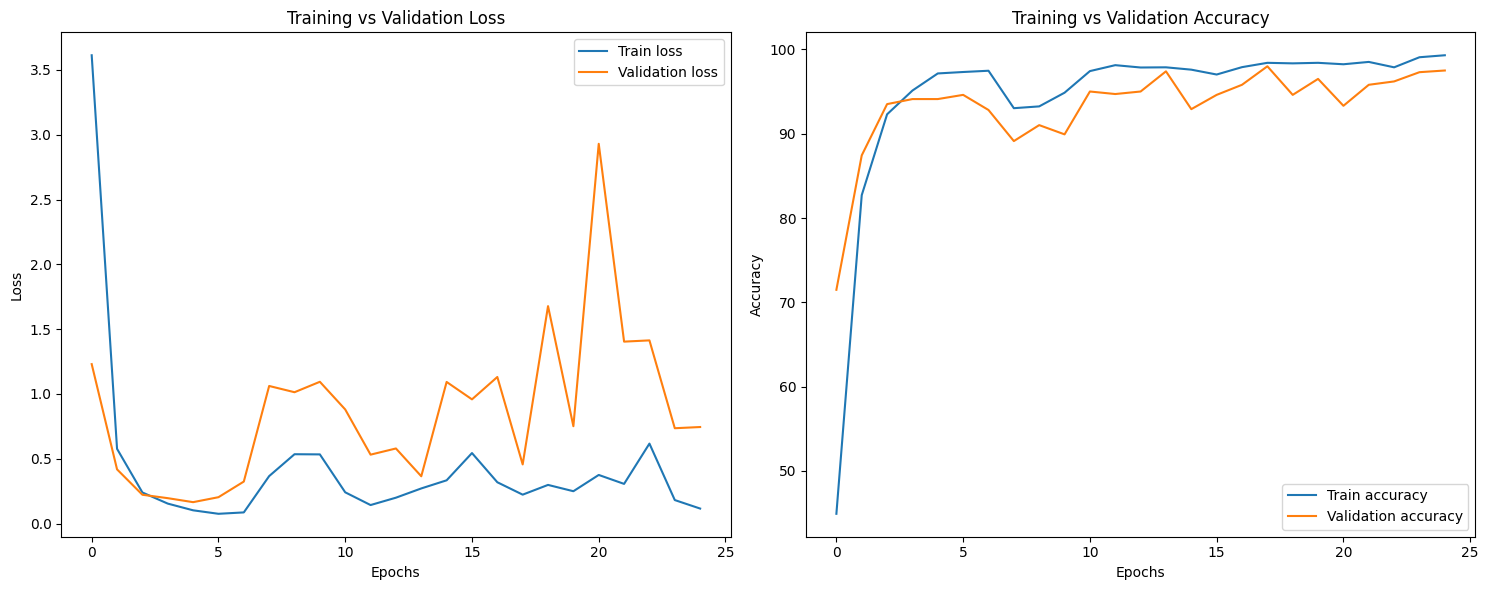

In [25]:
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(15,6))

axs[0].plot(total_loss_train_plot,label='Train loss')
axs[0].plot(total_loss_val_plot,label='Validation loss')
axs[0].set_title("Training vs Validation Loss")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()

axs[1].plot(total_acc_train_plot,label='Train accuracy')
axs[1].plot(total_acc_val_plot,label='Validation accuracy')
axs[1].set_title("Training vs Validation Accuracy")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy")
axs[1].legend()

plt.tight_layout()
plt.show()
